In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn sqlalchemy requests psycopg2-binary


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import requests  # Communicate with API
from sqlalchemy import create_engine  # DataBase Connection

# Step:1 Collect The Data From API Add it into CSV File

In [4]:
API_Base_URL = "https://uber-6e65.onrender.com"

In [5]:
response=requests.get(f"{API_Base_URL}/api/v1")
response.json()

{'message': '🚗 Welcome to Uber Rides India API',
 'version': '1.0.0',
 'total_records': {'raw': 51250, 'sample': 100},
 'endpoints': {'documentation': '/docs',
  'alternative_docs': '/redoc',
  'health_check': '/health',
  'statistics': '/stats',
  'rides': {'all_raw': '/rides/raw',
   'sample': '/rides/sample',
   'by_id': '/rides/{ride_id}',
   'by_city': '/rides/city/{city_name}',
   'filter': '/rides/filter'}}}

In [6]:
all_Data=[]
skip=0
batch_size=1000
try:
  response=requests.get(f"{API_Base_URL}/api/v1")
  total_Records=response.json()['total_records']['raw']


  while skip<total_Records:
    url=f"{API_Base_URL}/rides/raw?skip={skip}&limit={batch_size}"
    res=requests.get(url).json()
    data_batch=res.get('data',[])
    all_Data.extend(data_batch)
    skip+=batch_size
    print(f"Fetched{len(data_batch)} records. Total records fetched:{skip}/{total_Records}")

  df_raw=pd.DataFrame(all_Data)
  print(df_raw.shape)
  df_raw.head()
  
except Exception as e:
  print(e)

Fetched1000 records. Total records fetched:1000/51250
Fetched1000 records. Total records fetched:2000/51250
Fetched1000 records. Total records fetched:3000/51250
Fetched1000 records. Total records fetched:4000/51250
Fetched1000 records. Total records fetched:5000/51250
Fetched1000 records. Total records fetched:6000/51250
Fetched1000 records. Total records fetched:7000/51250
Fetched1000 records. Total records fetched:8000/51250
Fetched1000 records. Total records fetched:9000/51250
Fetched1000 records. Total records fetched:10000/51250
Fetched1000 records. Total records fetched:11000/51250
Fetched1000 records. Total records fetched:12000/51250
Fetched1000 records. Total records fetched:13000/51250
Fetched1000 records. Total records fetched:14000/51250
Fetched1000 records. Total records fetched:15000/51250
Fetched1000 records. Total records fetched:16000/51250
Fetched1000 records. Total records fetched:17000/51250
Fetched1000 records. Total records fetched:18000/51250
Fetched1000 records

In [7]:
df_raw.head()

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,NaN,0.0,0.00,NaN,No Driver Available,NaN,NaN,Failed
1,UBR01020807,2025-05-07 01:26:20.803557,2025-05-07,01:26:20.803557,1,Wednesday,May,0,Chennai,Mylapore,...,Cash,Other,13.6,0.0,95.26,SAVE20,NaN,35.6,275.78,Success
2,UBR01002907,2025-04-04 21:50:42.803557,2025-04-04,21:50:42.803557,21,Friday,April,0,Pune,Viman Nagar,...,Debit Card,Work,6.4,0.0,35.17,SAVE20,NaN,47.0,270.06,Success
3,UBR01029316,2025-02-10 11:19:47.803557,2025-02-10,11:19:47.803557,11,Monday,February,0,Chennai,Tambaram,...,Amazon Pay,Social,3.3,50.0,0.00,NaN,NaN,27.9,722.24,Success
4,UBR01024653,2025-01-15 22:28:42.803557,2025-01-15,22:28:42.803557,22,Wednesday,January,0,Kolkata,Park Street,...,UPI,Party,2.1,0.0,0.00,NaN,NaN,50.0,239.50,Success


In [8]:
df_raw.shape

(51250, 43)

In [9]:
df_raw.to_csv("uber_data_raw.csv", index=False)

# Step:2 Data Cleaning [Get Data From Raw table Clean and Save As Cleaned Table]

In [10]:
data_raw=pd.read_csv('uber_data_raw.csv')

In [11]:
data_raw.head()

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,NaN,0.0,0.00,NaN,No Driver Available,NaN,NaN,Failed
1,UBR01020807,2025-05-07 01:26:20.803557,2025-05-07,01:26:20.803557,1,Wednesday,May,0,Chennai,Mylapore,...,Cash,Other,13.6,0.0,95.26,SAVE20,NaN,35.6,275.78,Success
2,UBR01002907,2025-04-04 21:50:42.803557,2025-04-04,21:50:42.803557,21,Friday,April,0,Pune,Viman Nagar,...,Debit Card,Work,6.4,0.0,35.17,SAVE20,NaN,47.0,270.06,Success
3,UBR01029316,2025-02-10 11:19:47.803557,2025-02-10,11:19:47.803557,11,Monday,February,0,Chennai,Tambaram,...,Amazon Pay,Social,3.3,50.0,0.00,NaN,NaN,27.9,722.24,Success
4,UBR01024653,2025-01-15 22:28:42.803557,2025-01-15,22:28:42.803557,22,Wednesday,January,0,Kolkata,Park Street,...,UPI,Party,2.1,0.0,0.00,NaN,NaN,50.0,239.50,Success


In [12]:
data_raw.shape

(51250, 43)

In [13]:
data_raw.describe()

,Hour_of_Day,Is_Weekend,Pickup_Latitude,Pickup_Longitude,Dropoff_Latitude,Dropoff_Longitude,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,...,Temperature_Celsius,Surge_Multiplier,Is_Scheduled_Ride,Is_Shared_Ride,Number_of_Passengers,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,ETA_Minutes,Fare_Price
count,51250.000000,51250.000000,51250.000000,51250.000000,51250.000000,51250.000000,51250.000000,48013.000000,51250.000000,51250.000000,...,50174.000000,51250.000000,51250.000000,51250.000000,51250.000000,39663.000000,48700.000000,51250.000000,42516.000000,42516.000000
mean,11.553541,0.284059,19.413620,77.685127,19.413284,77.684840,14.880557,4.555666,250.781463,0.130275,...,28.521896,1.602925,0.148254,0.079415,2.407766,7.982510,8.559754,12.182804,57.725489,573.368307
std,6.895345,0.450969,4.943512,4.830518,4.942605,4.830684,9.442052,0.318096,144.865200,0.069450,...,7.791288,0.377348,0.355355,0.270387,1.114619,4.046074,22.072714,26.247041,39.781366,481.608154
min,0.000000,0.000000,12.840052,72.500022,12.840284,72.500042,0.500000,4.000000,0.000000,0.010000,...,15.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,3.800000,40.510000
25%,6.000000,0.000000,13.205789,73.747102,13.206467,73.748169,8.050000,4.300000,125.000000,0.070000,...,21.800000,1.300000,0.000000,0.000000,1.000000,4.500000,0.000000,0.000000,30.600000,256.217500
50%,12.000000,0.000000,18.638537,77.469096,18.637874,77.468158,12.970000,4.600000,251.000000,0.130000,...,28.500000,1.600000,0.000000,0.000000,2.000000,8.000000,0.000000,0.000000,47.500000,435.680000
75%,18.000000,1.000000,22.648005,80.163414,22.648089,80.163588,19.440000,4.800000,376.000000,0.190000,...,35.200000,1.900000,0.000000,0.000000,3.000000,11.500000,0.000000,0.000000,72.800000,735.192500
max,23.000000,1.000000,28.879910,88.429981,28.879969,88.429994,66.190000,5.000000,500.000000,0.250000,...,42.000000,2.500000,1.000000,1.000000,4.000000,15.000000,100.000000,99.990000,400.500000,8897.651722


In [14]:
data_raw.describe(include='object')

C:\Users\NITHYANANTHAM.G\AppData\Local\Temp\ipykernel_5672\612823624.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_raw.describe(include='object')


,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Day_of_Week,Month,City,Pickup_Area,Dropoff_Area,Vehicle_Type,Customer_ID,Customer_Segment,Driver_ID,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason,Driver_Pickup_Status
count,51250,51250,51250,51250,51250,51250,51250,51250,51250,51250,51250,51250,51250,48173,47651,47723,48068,8090,8734,51250
unique,50000,49962,367,37950,7,12,16,240,120,10,38417,5,38390,8,6,9,12,5,5,2
top,UBR01008617,2025-08-06 16:57:11.803557,2025-03-09,01:46:57.803557,Tuesday,December,Kolkata,Rajarhat,Magarpatta,UberGo,CUST17209,Frequent,DRV71739,Fog,High,Paytm,Home,UBER100,Customer Cancelled,Success
freq,2,2,171,7,7443,4477,6185,460,494,5228,6,10336,6,6146,8012,5416,4083,1642,1796,42516


In [15]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 51250 entries, 0 to 51249
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Ride_ID                     51250 non-null  str    
 1   Booking_Timestamp           51250 non-null  str    
 2   Ride_Date                   51250 non-null  str    
 3   Ride_Time                   51250 non-null  str    
 4   Hour_of_Day                 51250 non-null  int64  
 5   Day_of_Week                 51250 non-null  str    
 6   Month                       51250 non-null  str    
 7   Is_Weekend                  51250 non-null  int64  
 8   City                        51250 non-null  str    
 9   Pickup_Area                 51250 non-null  str    
 10  Pickup_Latitude             51250 non-null  float64
 11  Pickup_Longitude            51250 non-null  float64
 12  Dropoff_Area                51250 non-null  str    
 13  Dropoff_Latitude            51250 non-null

In [16]:
data_raw.isna().sum()

Ride_ID                           0
Booking_Timestamp                 0
Ride_Date                         0
Ride_Time                         0
Hour_of_Day                       0
Day_of_Week                       0
Month                             0
Is_Weekend                        0
City                              0
Pickup_Area                       0
Pickup_Latitude                   0
Pickup_Longitude                  0
Dropoff_Area                      0
Dropoff_Latitude                  0
Dropoff_Longitude                 0
Distance_KM                       0
Vehicle_Type                      0
Customer_ID                       0
Customer_Segment                  0
Customer_Rating                3237
Previous_Rides_Count              0
Customer_Cancellation_Rate        0
Driver_ID                         0
Driver_Rating                  3942
Driver_Experience_Years           0
Driver_Acceptance_Rate            0
Weather_Condition              3077
Temperature_Celsius         

In [17]:
data_raw.isna().mean()*100

Ride_ID                        0.000000
Booking_Timestamp              0.000000
Ride_Date                      0.000000
Ride_Time                      0.000000
Hour_of_Day                    0.000000
Day_of_Week                    0.000000
Month                          0.000000
Is_Weekend                     0.000000
City                           0.000000
Pickup_Area                    0.000000
Pickup_Latitude                0.000000
Pickup_Longitude               0.000000
Dropoff_Area                   0.000000
Dropoff_Latitude               0.000000
Dropoff_Longitude              0.000000
Distance_KM                    0.000000
Vehicle_Type                   0.000000
Customer_ID                    0.000000
Customer_Segment               0.000000
Customer_Rating                6.316098
Previous_Rides_Count           0.000000
Customer_Cancellation_Rate     0.000000
Driver_ID                      0.000000
Driver_Rating                  7.691707
Driver_Experience_Years        0.000000


# Drop Dulicates

In [18]:
data_raw.duplicated().sum()

np.int64(1058)

In [19]:
data_raw.drop_duplicates(inplace=True)

In [20]:
data_raw.duplicated().sum()

np.int64(0)

# Handle Null and  Change Datatype

In [21]:
data_raw.isna().mean()*100

Ride_ID                        0.000000
Booking_Timestamp              0.000000
Ride_Date                      0.000000
Ride_Time                      0.000000
Hour_of_Day                    0.000000
Day_of_Week                    0.000000
Month                          0.000000
Is_Weekend                     0.000000
City                           0.000000
Pickup_Area                    0.000000
Pickup_Latitude                0.000000
Pickup_Longitude               0.000000
Dropoff_Area                   0.000000
Dropoff_Latitude               0.000000
Dropoff_Longitude              0.000000
Distance_KM                    0.000000
Vehicle_Type                   0.000000
Customer_ID                    0.000000
Customer_Segment               0.000000
Customer_Rating                6.313755
Previous_Rides_Count           0.000000
Customer_Cancellation_Rate     0.000000
Driver_ID                      0.000000
Driver_Rating                  7.652614
Driver_Experience_Years        0.000000


<Axes: >

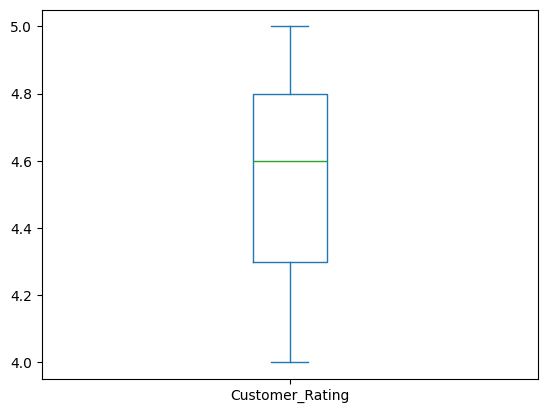

In [22]:
data_raw['Customer_Rating'].plot(kind='box')

In [23]:
data_raw['Customer_Rating'].mean()

np.float64(4.555825872445399)

In [24]:
data_raw['Customer_Rating'].median()

np.float64(4.6)

In [25]:
!pip install scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: ylabel='Density'>

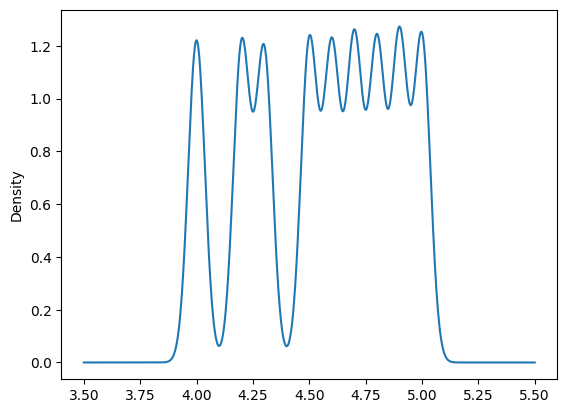

In [26]:
data_raw['Customer_Rating'].plot(kind='kde')

In [27]:
data_raw['Customer_Rating'] = data_raw['Customer_Rating'].fillna(data_raw['Customer_Rating'].median())

<Axes: >

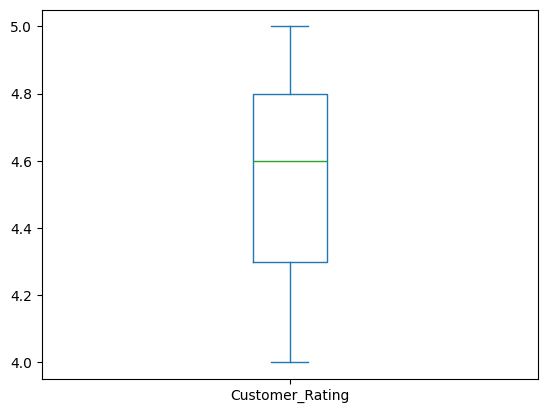

In [28]:
data_raw['Customer_Rating'].plot(kind='box')

In [29]:
data_raw['Customer_Rating'].median()

np.float64(4.6)

<Axes: >

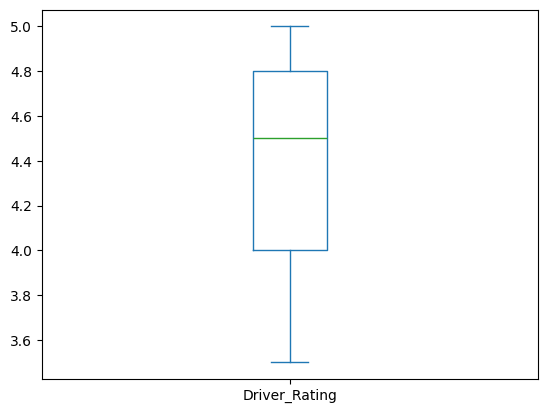

In [30]:
data_raw['Driver_Rating'].plot(kind='box')

In [31]:
numerical_Data = data_raw.select_dtypes(include=['int64', 'float64'])
cat_data = data_raw.select_dtypes(include=['object'])

C:\Users\NITHYANANTHAM.G\AppData\Local\Temp\ipykernel_5672\3515127941.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_data = data_raw.select_dtypes(include=['object'])


In [32]:
numerical_Data.isna().sum()

Hour_of_Day                       0
Is_Weekend                        0
Pickup_Latitude                   0
Pickup_Longitude                  0
Dropoff_Latitude                  0
Dropoff_Longitude                 0
Distance_KM                       0
Customer_Rating                   0
Previous_Rides_Count              0
Customer_Cancellation_Rate        0
Driver_Rating                  3841
Driver_Experience_Years           0
Driver_Acceptance_Rate            0
Temperature_Celsius            1038
Surge_Multiplier                  0
Is_Scheduled_Ride                 0
Is_Shared_Ride                    0
Number_of_Passengers              0
Waiting_Time_Minutes          11341
Tip_Amount                     2505
Discount_Applied                  0
ETA_Minutes                    8542
Fare_Price                     8542
dtype: int64

In [33]:
numerical_Data.isna().mean()*100

Hour_of_Day                    0.000000
Is_Weekend                     0.000000
Pickup_Latitude                0.000000
Pickup_Longitude               0.000000
Dropoff_Latitude               0.000000
Dropoff_Longitude              0.000000
Distance_KM                    0.000000
Customer_Rating                0.000000
Previous_Rides_Count           0.000000
Customer_Cancellation_Rate     0.000000
Driver_Rating                  7.652614
Driver_Experience_Years        0.000000
Driver_Acceptance_Rate         0.000000
Temperature_Celsius            2.068059
Surge_Multiplier               0.000000
Is_Scheduled_Ride              0.000000
Is_Shared_Ride                 0.000000
Number_of_Passengers           0.000000
Waiting_Time_Minutes          22.595234
Tip_Amount                     4.990835
Discount_Applied               0.000000
ETA_Minutes                   17.018648
Fare_Price                    17.018648
dtype: float64

<Axes: ylabel='Frequency'>

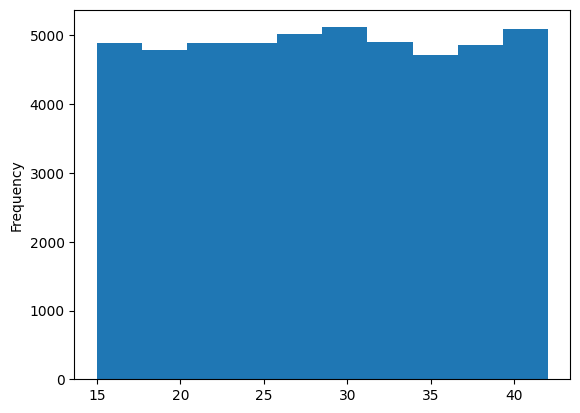

In [34]:
data_raw['Temperature_Celsius'].plot(kind='hist')

In [35]:
len(data_raw['Temperature_Celsius'].unique())

272

In [36]:
data_raw['Temperature_Celsius'] = data_raw['Temperature_Celsius'].fillna(data_raw['Temperature_Celsius'].median())

<Axes: >

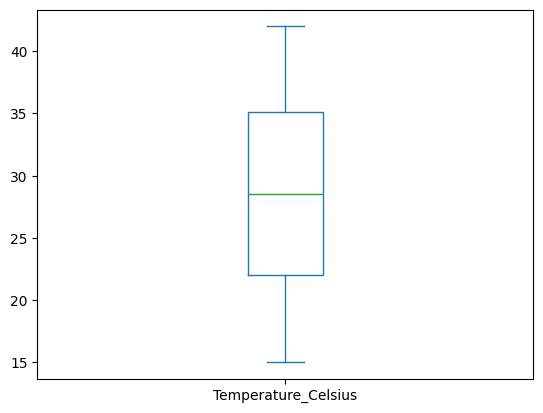

In [37]:
data_raw['Temperature_Celsius'].plot(kind='box')

In [38]:
data_raw['Driver_Rating'] = data_raw['Driver_Rating'].fillna(
    data_raw['Driver_Rating'].median())

In [39]:
numerical_Data.isna().mean()*100

Hour_of_Day                    0.000000
Is_Weekend                     0.000000
Pickup_Latitude                0.000000
Pickup_Longitude               0.000000
Dropoff_Latitude               0.000000
Dropoff_Longitude              0.000000
Distance_KM                    0.000000
Customer_Rating                0.000000
Previous_Rides_Count           0.000000
Customer_Cancellation_Rate     0.000000
Driver_Rating                  7.652614
Driver_Experience_Years        0.000000
Driver_Acceptance_Rate         0.000000
Temperature_Celsius            2.068059
Surge_Multiplier               0.000000
Is_Scheduled_Ride              0.000000
Is_Shared_Ride                 0.000000
Number_of_Passengers           0.000000
Waiting_Time_Minutes          22.595234
Tip_Amount                     4.990835
Discount_Applied               0.000000
ETA_Minutes                   17.018648
Fare_Price                    17.018648
dtype: float64

<Axes: >

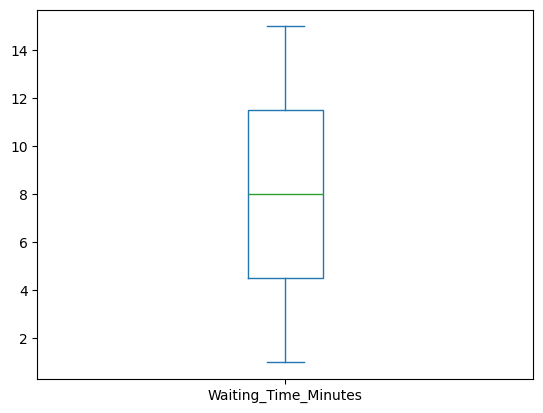

In [40]:
data_raw['Waiting_Time_Minutes'].plot(kind='box')

<Axes: ylabel='Frequency'>

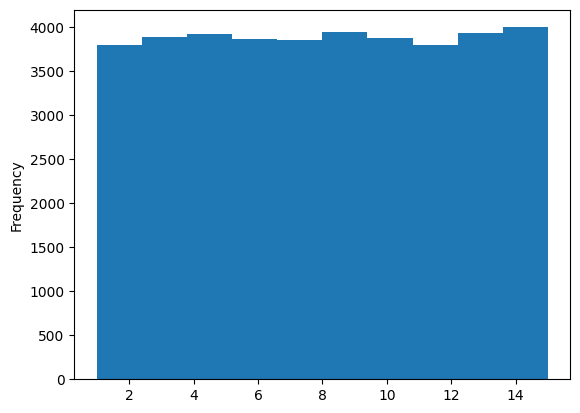

In [41]:
data_raw['Waiting_Time_Minutes'].plot(kind='hist')

In [44]:
data_raw[(data_raw['Waiting_Time_Minutes'].isna())&(data_raw['Driver_Pickup_Status'] == 'Success')]

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
14,UBR01005227,2025-10-25 22:29:25.803557,2025-10-25,22:29:25.803557,22,Saturday,October,1,Delhi,Rohini,...,Cash,Airport,NaN,0.0,0.00,NaN,NaN,177.5,1863.53,Success
56,UBR01013047,2025-04-23 19:54:15.803557,2025-04-23,19:54:15.803557,19,Wednesday,April,0,Pune,Koregaon Park,...,UPI,Meeting,NaN,0.0,0.00,NaN,NaN,47.6,240.01,Success
67,UBR01010723,2025-05-05 21:34:36.803557,2025-05-05,21:34:36.803557,21,Monday,May,0,Pune,Deccan,...,Wallet,Airport,NaN,0.0,0.00,NaN,NaN,56.6,722.85,Success
70,UBR01048379,2025-08-12 06:00:04.803557,2025-08-12,06:00:04.803557,6,Tuesday,August,0,Delhi,Lajpat Nagar,...,Credit Card,NaN,NaN,0.0,48.44,UBER100,NaN,57.1,173.96,Success
74,UBR01012691,2025-07-31 15:09:47.803557,2025-07-31,15:09:47.803557,15,Thursday,July,0,Bangalore,Indiranagar,...,NaN,Work,NaN,0.0,0.00,NaN,NaN,110.7,345.77,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51178,UBR01006873,2025-08-22 02:02:10.803557,2025-08-22,02:02:10.803557,2,Friday,August,0,Ahmedabad,Gota,...,Amazon Pay,Meeting,NaN,0.0,71.50,SAVE20,NaN,49.7,836.20,Success
51194,UBR01044974,2025-06-03 20:14:47.803557,2025-06-03,20:14:47.803557,20,Tuesday,June,0,Bangalore,JP Nagar,...,Amazon Pay,Social,NaN,0.0,0.00,NaN,NaN,116.8,1911.19,Success
51218,UBR01035773,2025-11-02 00:57:35.803557,2025-11-02,00:57:35.803557,0,Sunday,November,1,Chennai,Perungudi,...,Google Pay,Restaurant,NaN,10.0,0.00,NaN,NaN,73.3,315.18,Success
51222,UBR01018431,2025-01-22 16:58:43.803557,2025-01-22,16:58:43.803557,16,Wednesday,January,0,Bangalore,Whitefield,...,Debit Card,Party,NaN,0.0,0.00,NaN,NaN,65.2,338.64,Success


In [45]:
data_raw[(data_raw['Driver_Pickup_Status'] == 'Failed')]

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,NaN,0.0,0.0,NaN,No Driver Available,NaN,NaN,Failed
12,UBR01048841,2025-07-11 20:33:31.803557,2025-07-11,20:33:31.803557,20,Friday,July,0,Delhi,Rajouri Garden,...,PhonePe,Social,NaN,0.0,0.0,NaN,Driver Cancelled,NaN,NaN,Failed
19,UBR01049794,2025-04-21 16:39:04.803557,2025-04-21,16:39:04.803557,16,Monday,April,0,Mumbai,Colaba,...,Credit Card,Restaurant,NaN,0.0,0.0,NaN,Driver Not Responding,NaN,NaN,Failed
24,UBR01032054,2025-05-04 05:03:25.803557,2025-05-04,05:03:25.803557,5,Sunday,May,1,HYDERABAD,Jubilee Hills,...,Google Pay,Shopping,NaN,0.0,0.0,NaN,Driver Not Responding,NaN,NaN,Failed
28,UBR01012370,2025-09-12 04:02:28.803557,2025-09-12,04:02:28.803557,4,Friday,September,0,Mumbai,Andheri,...,Paytm,Work,NaN,0.0,0.0,NaN,No Driver Available,NaN,NaN,Failed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51215,UBR01031551,2025-06-04 00:17:51.803557,2025-06-04,00:17:51.803557,0,Wednesday,June,0,Pune,Hadapsar,...,Google Pay,Restaurant,NaN,0.0,90.8,FIRST50,Long Wait Time,NaN,NaN,Failed
51216,UBR01001267,2025-05-29 19:13:44.803557,2025-05-29,19:13:44.803557,19,Thursday,May,0,Chennai,Anna Nagar,...,Debit Card,Entertainment,NaN,0.0,0.0,NaN,Driver Not Responding,NaN,NaN,Failed
51219,UBR01019118,2025-11-06 05:21:39.803557,2025-11-06,05:21:39.803557,5,Thursday,November,0,Delhi,Saket,...,PhonePe,Hospital,NaN,0.0,0.0,NaN,Driver Cancelled,NaN,NaN,Failed
51228,UBR01028693,2025-08-11 04:03:00.803557,2025-08-11,04:03:00.803557,4,Monday,August,0,Chennai,T Nagar,...,NaN,Party,NaN,0.0,0.0,NaN,Driver Not Responding,NaN,NaN,Failed


In [46]:
data_raw.isna().sum()

Ride_ID                           0
Booking_Timestamp                 0
Ride_Date                         0
Ride_Time                         0
Hour_of_Day                       0
Day_of_Week                       0
Month                             0
Is_Weekend                        0
City                              0
Pickup_Area                       0
Pickup_Latitude                   0
Pickup_Longitude                  0
Dropoff_Area                      0
Dropoff_Latitude                  0
Dropoff_Longitude                 0
Distance_KM                       0
Vehicle_Type                      0
Customer_ID                       0
Customer_Segment                  0
Customer_Rating                   0
Previous_Rides_Count              0
Customer_Cancellation_Rate        0
Driver_ID                         0
Driver_Rating                     0
Driver_Experience_Years           0
Driver_Acceptance_Rate            0
Weather_Condition              3020
Temperature_Celsius         

In [47]:
data_raw['Waiting_Time_Minutes'] = data_raw['Waiting_Time_Minutes'].fillna(0)

<Axes: >

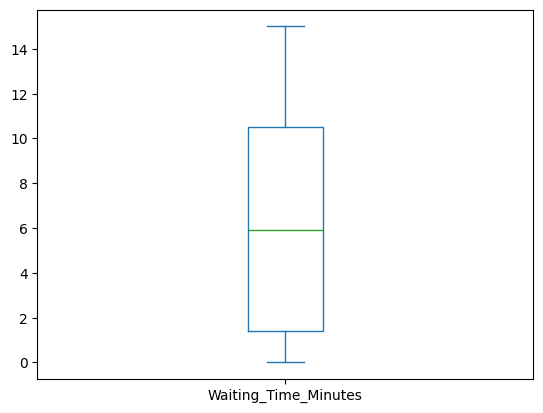

In [48]:
data_raw['Waiting_Time_Minutes'].plot(kind='box')

In [49]:
data_raw['Fare_Price'] = data_raw['Fare_Price'].fillna(0)
data_raw['ETA_Minutes'] = data_raw['ETA_Minutes'].fillna(0)

In [50]:
data_raw[data_raw['Driver_Pickup_Status'] == 'Failed']

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,0.0,0.0,0.0,NaN,No Driver Available,0.0,0.0,Failed
12,UBR01048841,2025-07-11 20:33:31.803557,2025-07-11,20:33:31.803557,20,Friday,July,0,Delhi,Rajouri Garden,...,PhonePe,Social,0.0,0.0,0.0,NaN,Driver Cancelled,0.0,0.0,Failed
19,UBR01049794,2025-04-21 16:39:04.803557,2025-04-21,16:39:04.803557,16,Monday,April,0,Mumbai,Colaba,...,Credit Card,Restaurant,0.0,0.0,0.0,NaN,Driver Not Responding,0.0,0.0,Failed
24,UBR01032054,2025-05-04 05:03:25.803557,2025-05-04,05:03:25.803557,5,Sunday,May,1,HYDERABAD,Jubilee Hills,...,Google Pay,Shopping,0.0,0.0,0.0,NaN,Driver Not Responding,0.0,0.0,Failed
28,UBR01012370,2025-09-12 04:02:28.803557,2025-09-12,04:02:28.803557,4,Friday,September,0,Mumbai,Andheri,...,Paytm,Work,0.0,0.0,0.0,NaN,No Driver Available,0.0,0.0,Failed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51215,UBR01031551,2025-06-04 00:17:51.803557,2025-06-04,00:17:51.803557,0,Wednesday,June,0,Pune,Hadapsar,...,Google Pay,Restaurant,0.0,0.0,90.8,FIRST50,Long Wait Time,0.0,0.0,Failed
51216,UBR01001267,2025-05-29 19:13:44.803557,2025-05-29,19:13:44.803557,19,Thursday,May,0,Chennai,Anna Nagar,...,Debit Card,Entertainment,0.0,0.0,0.0,NaN,Driver Not Responding,0.0,0.0,Failed
51219,UBR01019118,2025-11-06 05:21:39.803557,2025-11-06,05:21:39.803557,5,Thursday,November,0,Delhi,Saket,...,PhonePe,Hospital,0.0,0.0,0.0,NaN,Driver Cancelled,0.0,0.0,Failed
51228,UBR01028693,2025-08-11 04:03:00.803557,2025-08-11,04:03:00.803557,4,Monday,August,0,Chennai,T Nagar,...,NaN,Party,0.0,0.0,0.0,NaN,Driver Not Responding,0.0,0.0,Failed


In [51]:
data_raw[data_raw['Driver_Pickup_Status'] == 'Success']['Tip_Amount'].describe()

count    39561.000000
mean        10.339981
std         23.885643
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: Tip_Amount, dtype: float64

In [52]:
data_raw[(data_raw['Driver_Pickup_Status'] == 'Failed')&(data_raw['Tip_Amount'].isna())]

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
154,UBR01041902,2025-08-14 07:28:28.803557,2025-08-14,07:28:28.803557,7,Thursday,August,0,Mumbai,Malad,...,Cash,Hospital,0.0,NaN,0.00,NaN,Long Wait Time,0.0,0.0,Failed
519,UBR01017317,2025-02-02 16:47:30.803557,2025-02-02,16:47:30.803557,16,Sunday,February,1,Bangalore,Whitefield,...,Wallet,Home,0.0,NaN,0.00,NaN,Driver Cancelled,0.0,0.0,Failed
587,UBR01034161,2025-06-24 01:34:23.803557,2025-06-24,01:34:23.803557,1,Tuesday,June,0,Chennai,Perungudi,...,Google Pay,Work,0.0,NaN,0.00,NaN,Driver Not Responding,0.0,0.0,Failed
800,UBR01030389,2025-03-12 09:45:35.803557,2025-03-12,09:45:35.803557,9,Wednesday,March,0,Bangalore,Whitefield,...,NaN,Home,0.0,NaN,53.43,SAVE20,Driver Not Responding,0.0,0.0,Failed
899,UBR01036207,2025-09-05 00:11:19.803557,2025-09-05,00:11:19.803557,0,Friday,September,0,Bangalore,Koramangala,...,Amazon Pay,Hospital,0.0,NaN,65.51,NEWUSER,Driver Cancelled,0.0,0.0,Failed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50224,UBR01027285,2025-04-06 19:36:25.803557,2025-04-06,19:36:25.803557,19,Sunday,April,1,Delhi,Saket,...,PhonePe,Work,0.0,NaN,0.00,NaN,Long Wait Time,0.0,0.0,Failed
50341,UBR01015183,2025-05-23 05:08:50.803557,2025-05-23,05:08:50.803557,5,Friday,May,0,Delhi,Karol Bagh,...,Paytm,Other,0.0,NaN,0.00,NaN,Driver Cancelled,0.0,0.0,Failed
50874,UBR01049758,2025-10-30 02:36:21.803557,2025-10-30,02:36:21.803557,2,Thursday,October,0,Delhi,Nehru Place,...,Wallet,Hospital,0.0,NaN,0.00,NaN,Long Wait Time,0.0,0.0,Failed
51058,UBR01032562,2025-02-06 13:36:38.803557,2025-02-06,13:36:38.803557,13,Thursday,February,0,Bangalore,MG Road,...,Debit Card,Restaurant,0.0,NaN,0.00,NaN,No Driver Available,0.0,0.0,Failed


<Axes: >

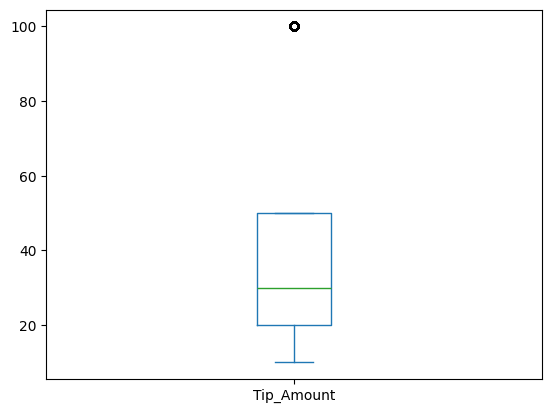

In [53]:
data_raw[(data_raw['Tip_Amount'] > 0)]['Tip_Amount'].plot(kind='box')

In [54]:
data_raw['Tip_Amount'].describe()

count    47687.000000
mean         8.578019
std         22.100169
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: Tip_Amount, dtype: float64

In [55]:
data_raw['Tip_Amount'] = data_raw['Tip_Amount'].fillna(0)

In [56]:
data_raw.isna().sum()

Ride_ID                           0
Booking_Timestamp                 0
Ride_Date                         0
Ride_Time                         0
Hour_of_Day                       0
Day_of_Week                       0
Month                             0
Is_Weekend                        0
City                              0
Pickup_Area                       0
Pickup_Latitude                   0
Pickup_Longitude                  0
Dropoff_Area                      0
Dropoff_Latitude                  0
Dropoff_Longitude                 0
Distance_KM                       0
Vehicle_Type                      0
Customer_ID                       0
Customer_Segment                  0
Customer_Rating                   0
Previous_Rides_Count              0
Customer_Cancellation_Rate        0
Driver_ID                         0
Driver_Rating                     0
Driver_Experience_Years           0
Driver_Acceptance_Rate            0
Weather_Condition              3020
Temperature_Celsius         

In [57]:
data_raw['Weather_Condition'].value_counts()

Weather_Condition
Fog              6032
Light Rain       5912
Sunny            5911
Cloudy           5896
Clear            5893
Drizzle          5857
Heavy Rain       5836
Partly Cloudy    5835
Name: count, dtype: int64

<Axes: xlabel='Weather_Condition'>

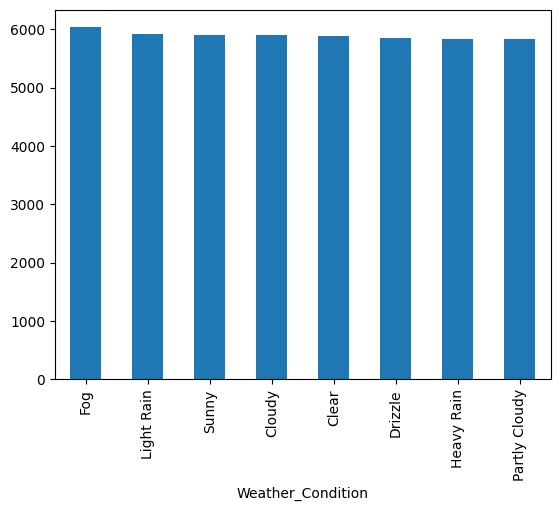

In [58]:
data_raw['Weather_Condition'].value_counts().plot(kind='bar')

<Axes: xlabel='Traffic_Condition'>

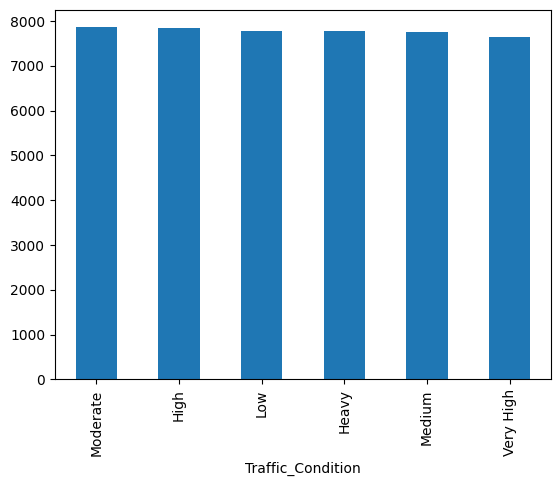

In [59]:
data_raw['Traffic_Condition'].value_counts().plot(kind='bar')

<Axes: xlabel='Payment_Method'>

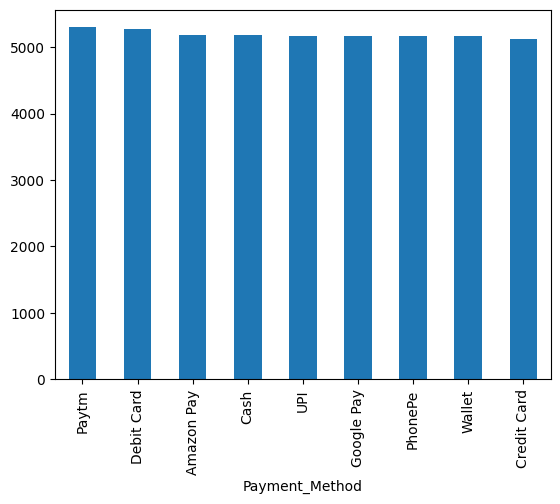

In [60]:
data_raw['Payment_Method'].value_counts().plot(kind='bar')

<Axes: xlabel='Ride_Purpose'>

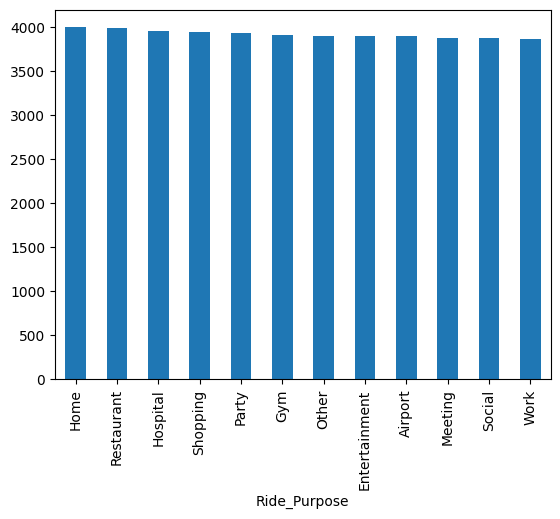

In [61]:
data_raw['Ride_Purpose'].value_counts().plot(kind='bar')

In [62]:
data_raw['Coupon_Code']

0           NaN
1        SAVE20
2        SAVE20
3           NaN
4           NaN
          ...  
51245       NaN
51246       NaN
51247       NaN
51248       NaN
51249       NaN
Name: Coupon_Code, Length: 50192, dtype: str

<Axes: xlabel='Coupon_Code'>

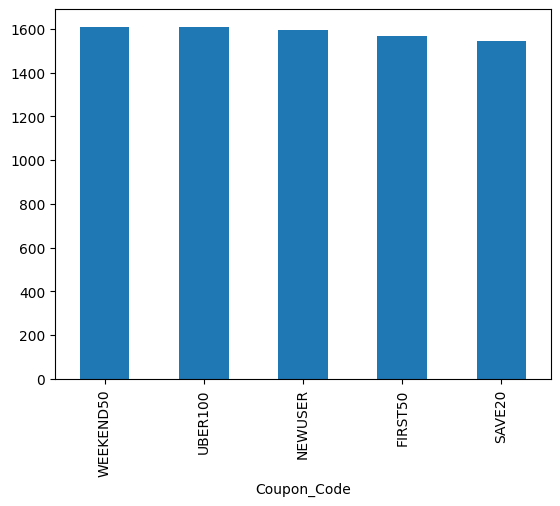

In [63]:
data_raw['Coupon_Code'].value_counts().plot(kind='bar')

<Axes: xlabel='Cancellation_Reason'>

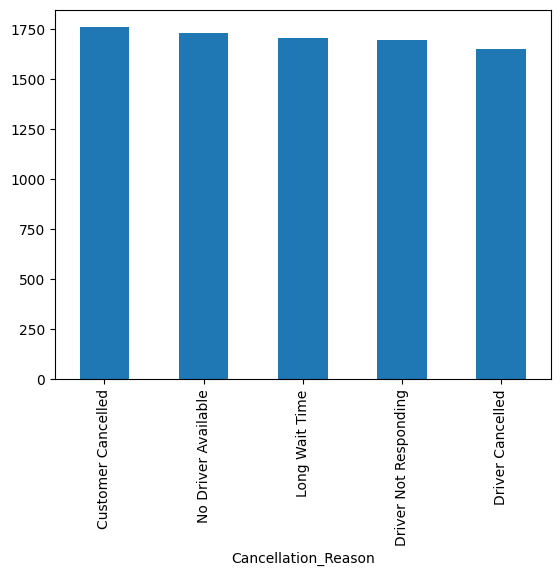

In [64]:
data_raw['Cancellation_Reason'].value_counts().plot(kind='bar')

In [65]:
data_raw['Coupon_Code'] = data_raw['Coupon_Code'].fillna('Not_Available')

In [66]:
data_raw['Cancellation_Reason'] = data_raw['Cancellation_Reason'].fillna('Not_Available')


In [67]:
data_raw.isna().sum()

Ride_ID                          0
Booking_Timestamp                0
Ride_Date                        0
Ride_Time                        0
Hour_of_Day                      0
Day_of_Week                      0
Month                            0
Is_Weekend                       0
City                             0
Pickup_Area                      0
Pickup_Latitude                  0
Pickup_Longitude                 0
Dropoff_Area                     0
Dropoff_Latitude                 0
Dropoff_Longitude                0
Distance_KM                      0
Vehicle_Type                     0
Customer_ID                      0
Customer_Segment                 0
Customer_Rating                  0
Previous_Rides_Count             0
Customer_Cancellation_Rate       0
Driver_ID                        0
Driver_Rating                    0
Driver_Experience_Years          0
Driver_Acceptance_Rate           0
Weather_Condition             3020
Temperature_Celsius              0
Traffic_Condition   

In [68]:
freq = data_raw['Weather_Condition'].value_counts(normalize=True)

In [70]:
freq

Weather_Condition
Fog              0.127872
Light Rain       0.125329
Sunny            0.125307
Cloudy           0.124989
Clear            0.124926
Drizzle          0.124163
Heavy Rain       0.123717
Partly Cloudy    0.123696
Name: proportion, dtype: float64

In [71]:
null_index = data_raw[data_raw['Weather_Condition'].isna()
                      ]['Weather_Condition']
null_index

3        NaN
6        NaN
9        NaN
10       NaN
14       NaN
        ... 
49081    NaN
49304    NaN
49434    NaN
50189    NaN
50399    NaN
Name: Weather_Condition, Length: 3020, dtype: str

In [72]:
freq.index

Index(['Fog', 'Light Rain', 'Sunny', 'Cloudy', 'Clear', 'Drizzle',
       'Heavy Rain', 'Partly Cloudy'],
      dtype='str', name='Weather_Condition')

In [73]:
freq.values

array([0.12787247, 0.12532858, 0.12530739, 0.1249894 , 0.1249258 ,
       0.12416264, 0.12371746, 0.12369626])

In [74]:
np.random.choice(freq.index, size=len(null_index),p=freq.values)

array(['Clear', 'Sunny', 'Fog', ..., 'Clear', 'Drizzle', 'Fog'],
      shape=(3020,), dtype=object)

In [75]:
data_raw.loc[null_index.index,'Weather_Condition'] = np.random.choice(freq.index,size=len(null_index),p=freq.values)

In [76]:
data_raw['Weather_Condition'].isna().sum()

np.int64(0)

<Axes: xlabel='Weather_Condition'>

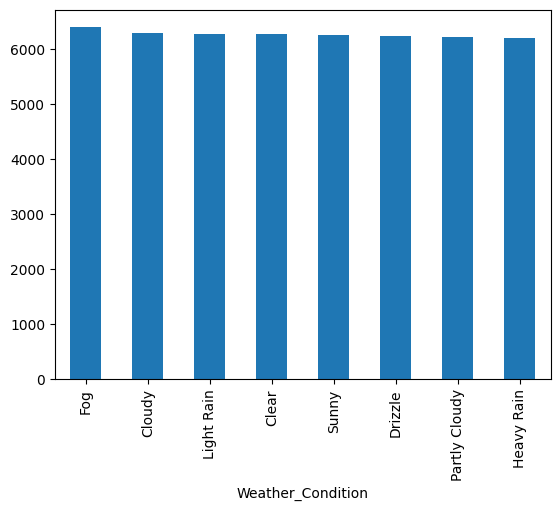

In [77]:
data_raw['Weather_Condition'].value_counts().plot(kind='bar')

In [78]:
def fill_nulls_by_freq(df, column_name):
  # To Get the Freq of the each Categorey
  freq = df[column_name].value_counts(normalize=True)
  null_index = df[df[column_name].isna()]
  df.loc[null_index.index, column_name] = np.random.choice(
      freq.index, size=len(null_index), p=freq.values)
  print(f'Null values filled successfully  for {column_name}')

In [79]:
Cat_Columns_List = ['Weather_Condition',
                    'Traffic_Condition', 'Payment_Method', 'Ride_Purpose']

for col in Cat_Columns_List:
  fill_nulls_by_freq(data_raw, col)

Null values filled successfully  for Weather_Condition
Null values filled successfully  for Traffic_Condition
Null values filled successfully  for Payment_Method
Null values filled successfully  for Ride_Purpose


In [80]:
data_raw.isna().sum()

Ride_ID                       0
Booking_Timestamp             0
Ride_Date                     0
Ride_Time                     0
Hour_of_Day                   0
Day_of_Week                   0
Month                         0
Is_Weekend                    0
City                          0
Pickup_Area                   0
Pickup_Latitude               0
Pickup_Longitude              0
Dropoff_Area                  0
Dropoff_Latitude              0
Dropoff_Longitude             0
Distance_KM                   0
Vehicle_Type                  0
Customer_ID                   0
Customer_Segment              0
Customer_Rating               0
Previous_Rides_Count          0
Customer_Cancellation_Rate    0
Driver_ID                     0
Driver_Rating                 0
Driver_Experience_Years       0
Driver_Acceptance_Rate        0
Weather_Condition             0
Temperature_Celsius           0
Traffic_Condition             0
Surge_Multiplier              0
Is_Scheduled_Ride             0
Is_Share

In [82]:
data_raw.head()

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,0.0,0.0,0.00,Not_Available,No Driver Available,0.0,0.00,Failed
1,UBR01020807,2025-05-07 01:26:20.803557,2025-05-07,01:26:20.803557,1,Wednesday,May,0,Chennai,Mylapore,...,Cash,Other,13.6,0.0,95.26,SAVE20,Not_Available,35.6,275.78,Success
2,UBR01002907,2025-04-04 21:50:42.803557,2025-04-04,21:50:42.803557,21,Friday,April,0,Pune,Viman Nagar,...,Debit Card,Work,6.4,0.0,35.17,SAVE20,Not_Available,47.0,270.06,Success
3,UBR01029316,2025-02-10 11:19:47.803557,2025-02-10,11:19:47.803557,11,Monday,February,0,Chennai,Tambaram,...,Amazon Pay,Social,3.3,50.0,0.00,Not_Available,Not_Available,27.9,722.24,Success
4,UBR01024653,2025-01-15 22:28:42.803557,2025-01-15,22:28:42.803557,22,Wednesday,January,0,Kolkata,Park Street,...,UPI,Party,2.1,0.0,0.00,Not_Available,Not_Available,50.0,239.50,Success


In [83]:
data_raw.shape

(50192, 43)

In [84]:
data_raw.columns

Index(['Ride_ID', 'Booking_Timestamp', 'Ride_Date', 'Ride_Time', 'Hour_of_Day',
       'Day_of_Week', 'Month', 'Is_Weekend', 'City', 'Pickup_Area',
       'Pickup_Latitude', 'Pickup_Longitude', 'Dropoff_Area',
       'Dropoff_Latitude', 'Dropoff_Longitude', 'Distance_KM', 'Vehicle_Type',
       'Customer_ID', 'Customer_Segment', 'Customer_Rating',
       'Previous_Rides_Count', 'Customer_Cancellation_Rate', 'Driver_ID',
       'Driver_Rating', 'Driver_Experience_Years', 'Driver_Acceptance_Rate',
       'Weather_Condition', 'Temperature_Celsius', 'Traffic_Condition',
       'Surge_Multiplier', 'Is_Scheduled_Ride', 'Is_Shared_Ride',
       'Number_of_Passengers', 'Payment_Method', 'Ride_Purpose',
       'Waiting_Time_Minutes', 'Tip_Amount', 'Discount_Applied', 'Coupon_Code',
       'Cancellation_Reason', 'ETA_Minutes', 'Fare_Price',
       'Driver_Pickup_Status'],
      dtype='str')

In [85]:
data_raw['Ride_ID'].value_counts()

Ride_ID
UBR01022219    2
UBR01036155    2
UBR01005035    2
UBR01018411    2
UBR01046616    2
              ..
UBR01011284    1
UBR01044732    1
UBR01038158    1
UBR01000860    1
UBR01015795    1
Name: count, Length: 50000, dtype: int64

In [86]:
data_raw[data_raw['Ride_ID'] == 'UBR01015048']

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
4898,UBR01015048,2025-06-22 04:55:12.803557,2025-06-22,04:55:12.803557,4,Sunday,June,1,Chennai,Anna Nagar,...,Wallet,Gym,14.9,10.0,0.0,Not_Available,Not_Available,80.2,995.61,Success
49753,UBR01015048,2025-06-22 04:55:12.803557,2025-06-22,04:55:12.803557,4,Sunday,June,1,Chennai,Anna Nagar,...,Wallet,Gym,14.9,10.0,0.0,Not_Available,Not_Available,80.2,995.61,Success


In [87]:
data_raw['Ride_ID'].duplicated().sum()

np.int64(192)

In [88]:
data_raw.drop_duplicates(subset=['Ride_ID'], inplace=True)

In [89]:
data_raw['Ride_ID'].value_counts()

Ride_ID
UBR01042298    1
UBR01020807    1
UBR01002907    1
UBR01029316    1
UBR01024653    1
              ..
UBR01011284    1
UBR01044732    1
UBR01038158    1
UBR01000860    1
UBR01015795    1
Name: count, Length: 50000, dtype: int64

In [90]:
data_raw.head()

,Ride_ID,Booking_Timestamp,Ride_Date,Ride_Time,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,UBR01042298,2025-06-28 20:32:59.803557,2025-06-28,20:32:59.803557,20,Saturday,June,1,Hyderabad,Madhapur,...,Wallet,Home,0.0,0.0,0.00,Not_Available,No Driver Available,0.0,0.00,Failed
1,UBR01020807,2025-05-07 01:26:20.803557,2025-05-07,01:26:20.803557,1,Wednesday,May,0,Chennai,Mylapore,...,Cash,Other,13.6,0.0,95.26,SAVE20,Not_Available,35.6,275.78,Success
2,UBR01002907,2025-04-04 21:50:42.803557,2025-04-04,21:50:42.803557,21,Friday,April,0,Pune,Viman Nagar,...,Debit Card,Work,6.4,0.0,35.17,SAVE20,Not_Available,47.0,270.06,Success
3,UBR01029316,2025-02-10 11:19:47.803557,2025-02-10,11:19:47.803557,11,Monday,February,0,Chennai,Tambaram,...,Amazon Pay,Social,3.3,50.0,0.00,Not_Available,Not_Available,27.9,722.24,Success
4,UBR01024653,2025-01-15 22:28:42.803557,2025-01-15,22:28:42.803557,22,Wednesday,January,0,Kolkata,Park Street,...,UPI,Party,2.1,0.0,0.00,Not_Available,Not_Available,50.0,239.50,Success


In [91]:
data_raw.shape

(50000, 43)

In [92]:
data_raw['Driver_ID'].value_counts()

Driver_ID
DRV72881    6
DRV71739    5
DRV53397    5
DRV46895    5
DRV87643    5
           ..
DRV29043    1
DRV68130    1
DRV33446    1
DRV10491    1
DRV10542    1
Name: count, Length: 38390, dtype: int64

In [93]:
data_raw['Driver_ID'].nunique()

38390

In [94]:
data_raw.drop(['Ride_ID', 'Booking_Timestamp','Ride_Date','Ride_Time','Pickup_Latitude','Pickup_Longitude','Dropoff_Latitude','Dropoff_Longitude','Customer_ID','Driver_ID'],axis=1,inplace=True)

In [95]:
data_raw

,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,Dropoff_Area,Distance_KM,Vehicle_Type,Customer_Segment,...,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,20,Saturday,June,1,Hyderabad,Madhapur,Ameerpet,21.47,UberAuto,New,...,Wallet,Home,0.0,0.0,0.00,Not_Available,No Driver Available,0.0,0.00,Failed
1,1,Wednesday,May,0,Chennai,Mylapore,Nungambakkam,17.83,UberGo,Occasional,...,Cash,Other,13.6,0.0,95.26,SAVE20,Not_Available,35.6,275.78,Success
2,21,Friday,April,0,Pune,Viman Nagar,Hinjewadi,8.90,UberAuto,Regular,...,Debit Card,Work,6.4,0.0,35.17,SAVE20,Not_Available,47.0,270.06,Success
3,11,Monday,February,0,Chennai,Tambaram,Guindy,7.03,UberPremier,Premium,...,Amazon Pay,Social,3.3,50.0,0.00,Not_Available,Not_Available,27.9,722.24,Success
4,22,Wednesday,January,0,Kolkata,Park Street,Howrah,13.79,UberAuto,New,...,UPI,Party,2.1,0.0,0.00,Not_Available,Not_Available,50.0,239.50,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,7,Tuesday,November,0,Hyderabad,Kukatpally,Secunderabad,10.44,UberMoto,Frequent,...,Cash,Meeting,6.9,0.0,0.00,Not_Available,Not_Available,63.7,321.67,Success
51246,4,Monday,April,0,Ahmedabad,Navrangpura,Naranpura,13.76,UberMoto,New,...,PhonePe,Social,7.3,0.0,0.00,Not_Available,Not_Available,54.1,223.22,Success
51247,18,Tuesday,May,0,Chennai,Perungudi,Sholinganallur,13.16,Uber X,Frequent,...,PhonePe,Party,13.7,0.0,0.00,Not_Available,Not_Available,42.9,565.34,Success
51248,16,Friday,June,0,Bangalore,Koramangala,MG Road,21.44,Uber Moto,Frequent,...,UPI,Hospital,13.8,0.0,87.39,Not_Available,Not_Available,123.1,472.46,Success


In [96]:
X_Features = data_raw.drop(
    ['ETA_Minutes', 'Fare_Price', 'Driver_Pickup_Status'], axis=1)
y_Target = data_raw[['ETA_Minutes','Fare_Price','Driver_Pickup_Status']]

In [97]:
X_Features

,Hour_of_Day,Day_of_Week,Month,Is_Weekend,City,Pickup_Area,Dropoff_Area,Distance_KM,Vehicle_Type,Customer_Segment,...,Is_Scheduled_Ride,Is_Shared_Ride,Number_of_Passengers,Payment_Method,Ride_Purpose,Waiting_Time_Minutes,Tip_Amount,Discount_Applied,Coupon_Code,Cancellation_Reason
0,20,Saturday,June,1,Hyderabad,Madhapur,Ameerpet,21.47,UberAuto,New,...,0,0,4,Wallet,Home,0.0,0.0,0.00,Not_Available,No Driver Available
1,1,Wednesday,May,0,Chennai,Mylapore,Nungambakkam,17.83,UberGo,Occasional,...,0,0,2,Cash,Other,13.6,0.0,95.26,SAVE20,Not_Available
2,21,Friday,April,0,Pune,Viman Nagar,Hinjewadi,8.90,UberAuto,Regular,...,0,0,3,Debit Card,Work,6.4,0.0,35.17,SAVE20,Not_Available
3,11,Monday,February,0,Chennai,Tambaram,Guindy,7.03,UberPremier,Premium,...,0,0,4,Amazon Pay,Social,3.3,50.0,0.00,Not_Available,Not_Available
4,22,Wednesday,January,0,Kolkata,Park Street,Howrah,13.79,UberAuto,New,...,0,0,4,UPI,Party,2.1,0.0,0.00,Not_Available,Not_Available
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,7,Tuesday,November,0,Hyderabad,Kukatpally,Secunderabad,10.44,UberMoto,Frequent,...,0,0,1,Cash,Meeting,6.9,0.0,0.00,Not_Available,Not_Available
51246,4,Monday,April,0,Ahmedabad,Navrangpura,Naranpura,13.76,UberMoto,New,...,0,0,3,PhonePe,Social,7.3,0.0,0.00,Not_Available,Not_Available
51247,18,Tuesday,May,0,Chennai,Perungudi,Sholinganallur,13.16,Uber X,Frequent,...,0,0,2,PhonePe,Party,13.7,0.0,0.00,Not_Available,Not_Available
51248,16,Friday,June,0,Bangalore,Koramangala,MG Road,21.44,Uber Moto,Frequent,...,0,0,3,UPI,Hospital,13.8,0.0,87.39,Not_Available,Not_Available


In [98]:
Cat_Featues = X_Features.select_dtypes(include=['object'])

C:\Users\NITHYANANTHAM.G\AppData\Local\Temp\ipykernel_5672\2484937312.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Cat_Featues = X_Features.select_dtypes(include=['object'])


In [99]:
Cat_Featues

,Day_of_Week,Month,City,Pickup_Area,Dropoff_Area,Vehicle_Type,Customer_Segment,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason
0,Saturday,June,Hyderabad,Madhapur,Ameerpet,UberAuto,New,Sunny,Very High,Wallet,Home,Not_Available,No Driver Available
1,Wednesday,May,Chennai,Mylapore,Nungambakkam,UberGo,Occasional,Cloudy,Moderate,Cash,Other,SAVE20,Not_Available
2,Friday,April,Pune,Viman Nagar,Hinjewadi,UberAuto,Regular,Cloudy,Very High,Debit Card,Work,SAVE20,Not_Available
3,Monday,February,Chennai,Tambaram,Guindy,UberPremier,Premium,Drizzle,Medium,Amazon Pay,Social,Not_Available,Not_Available
4,Wednesday,January,Kolkata,Park Street,Howrah,UberAuto,New,Partly Cloudy,High,UPI,Party,Not_Available,Not_Available
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,Tuesday,November,Hyderabad,Kukatpally,Secunderabad,UberMoto,Frequent,Fog,Heavy,Cash,Meeting,Not_Available,Not_Available
51246,Monday,April,Ahmedabad,Navrangpura,Naranpura,UberMoto,New,Light Rain,High,PhonePe,Social,Not_Available,Not_Available
51247,Tuesday,May,Chennai,Perungudi,Sholinganallur,Uber X,Frequent,Light Rain,Moderate,PhonePe,Party,Not_Available,Not_Available
51248,Friday,June,Bangalore,Koramangala,MG Road,Uber Moto,Frequent,Heavy Rain,Heavy,UPI,Hospital,Not_Available,Not_Available


In [100]:
Num_Features = X_Features.select_dtypes(include=['int64','float64','int32','int','float32','float'])

In [101]:
Num_Features

,Hour_of_Day,Is_Weekend,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,Driver_Rating,Driver_Experience_Years,Driver_Acceptance_Rate,Temperature_Celsius,Surge_Multiplier,Is_Scheduled_Ride,Is_Shared_Ride,Number_of_Passengers,Waiting_Time_Minutes,Tip_Amount,Discount_Applied
0,20,1,21.47,4.9,91,0.21,4.5,1,0.77,19.4,1.9,0,0,4,0.0,0.0,0.00
1,1,0,17.83,4.6,167,0.11,4.6,1,0.91,20.8,1.0,0,0,2,13.6,0.0,95.26
2,21,0,8.90,5.0,204,0.24,3.5,8,0.77,15.4,1.7,0,0,3,6.4,0.0,35.17
3,11,0,7.03,4.8,85,0.12,4.7,2,0.91,41.0,1.9,0,0,4,3.3,50.0,0.00
4,22,0,13.79,4.3,91,0.05,4.5,1,0.81,15.2,1.2,0,0,4,2.1,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,7,0,10.44,4.6,302,0.08,4.3,9,0.73,33.4,2.3,0,0,1,6.9,0.0,0.00
51246,4,0,13.76,4.2,231,0.14,4.9,2,0.81,32.3,1.5,0,0,3,7.3,0.0,0.00
51247,18,0,13.16,4.2,340,0.10,4.6,7,0.92,38.1,1.8,0,0,2,13.7,0.0,0.00
51248,16,0,21.44,4.9,42,0.05,4.3,10,0.78,32.4,2.0,0,0,3,13.8,0.0,87.39


In [102]:
Cat_Featues['Day_of_Week'].unique()

<StringArray>
['Saturday', 'Wednesday', 'Friday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str

In [103]:
Cat_Featues['City'] = Cat_Featues['City'].str.lower()

In [104]:
for col in Cat_Featues.columns:
  Cat_Featues[col] = Cat_Featues[col].str.lower().str.strip()
  print(f'{col}:{sorted(Cat_Featues[col].unique(), reverse=False)}')
  print('---'*20)

Day_of_Week:['friday', 'monday', 'saturday', 'sunday', 'thursday', 'tuesday', 'wednesday']
------------------------------------------------------------
Month:['april', 'august', 'december', 'february', 'january', 'july', 'june', 'march', 'may', 'november', 'october', 'september']
------------------------------------------------------------
City:['ahmedabad', 'bangalore', 'chennai', 'delhi', 'hyderabad', 'kolkata', 'mumbai', 'pune']
------------------------------------------------------------
Pickup_Area:['adyar', 'alipore', 'ameerpet', 'andheri', 'anna nagar', 'ashram road', 'aundh', 'ballygunge', 'banashankari', 'bandra', 'baner', 'banjara hills', 'barasat', 'begumpet', 'behala', 'bellandur', 'bodakdev', 'bopal', 'borivali', 'btm layout', 'cg road', 'chandkheda', 'chinchwad', 'chrompet', 'colaba', 'connaught place', 'dadar', 'deccan', 'dilsukhnagar', 'dum dum', 'dwarka', 'egmore', 'electronic city', 'esplanade', 'faridabad', 'gachibowli', 'gariahat', 'goregaon', 'gota', 'greater kaila

In [105]:
Cat_Featues['Vehicle_Type'].value_counts()

Vehicle_Type
ubergo          5096
uberxl          5058
uberauto        5032
uberx           5031
uberpremier     5011
uber premier    4975
ubermoto        4962
uber x          4960
uber moto       4950
uber go         4925
Name: count, dtype: int64

In [106]:
Cat_Featues['Vehicle_Type'].replace({'uber go': 'ubergo','uber x':'uberxl','uberx':'uberxl','uber premier':'uberpremier','uber moto':'ubermoto'}).value_counts()

Vehicle_Type
uberxl         15049
ubergo         10021
uberpremier     9986
ubermoto        9912
uberauto        5032
Name: count, dtype: int64

In [107]:
Cat_Featues['Vehicle_Type'] = Cat_Featues['Vehicle_Type'].replace({'uber go':'ubergo','uber x':'uberxl','uberx':'uberxl','uber premier':'uberpremier','uber moto':'ubermoto'})

In [108]:
Cat_Featues['Vehicle_Type'].value_counts()

Vehicle_Type
uberxl         15049
ubergo         10021
uberpremier     9986
ubermoto        9912
uberauto        5032
Name: count, dtype: int64

In [109]:
Cat_Featues['Traffic_Condition'].value_counts()

Traffic_Condition
moderate     8408
high         8387
medium       8350
low          8336
heavy        8322
very high    8197
Name: count, dtype: int64

In [110]:
Cat_Featues

,Day_of_Week,Month,City,Pickup_Area,Dropoff_Area,Vehicle_Type,Customer_Segment,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason
0,saturday,june,hyderabad,madhapur,ameerpet,uberauto,new,sunny,very high,wallet,home,not_available,no driver available
1,wednesday,may,chennai,mylapore,nungambakkam,ubergo,occasional,cloudy,moderate,cash,other,save20,not_available
2,friday,april,pune,viman nagar,hinjewadi,uberauto,regular,cloudy,very high,debit card,work,save20,not_available
3,monday,february,chennai,tambaram,guindy,uberpremier,premium,drizzle,medium,amazon pay,social,not_available,not_available
4,wednesday,january,kolkata,park street,howrah,uberauto,new,partly cloudy,high,upi,party,not_available,not_available
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,tuesday,november,hyderabad,kukatpally,secunderabad,ubermoto,frequent,fog,heavy,cash,meeting,not_available,not_available
51246,monday,april,ahmedabad,navrangpura,naranpura,ubermoto,new,light rain,high,phonepe,social,not_available,not_available
51247,tuesday,may,chennai,perungudi,sholinganallur,uberxl,frequent,light rain,moderate,phonepe,party,not_available,not_available
51248,friday,june,bangalore,koramangala,mg road,ubermoto,frequent,heavy rain,heavy,upi,hospital,not_available,not_available


In [111]:
Num_Features.describe()

,Hour_of_Day,Is_Weekend,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,Driver_Rating,Driver_Experience_Years,Driver_Acceptance_Rate,Temperature_Celsius,Surge_Multiplier,Is_Scheduled_Ride,Is_Shared_Ride,Number_of_Passengers,Waiting_Time_Minutes,Tip_Amount,Discount_Applied
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.55498,0.283620,14.874252,4.558694,250.794780,0.130285,4.401802,5.493380,0.840284,28.519104,1.603170,0.147960,0.079420,2.407700,6.176630,8.147600,12.189858
std,6.89526,0.450759,9.441232,0.308049,144.841988,0.069459,0.439462,2.867264,0.080799,7.714090,0.377158,0.355064,0.270396,1.114103,4.879937,21.615873,26.245347
min,0.00000,0.000000,0.500000,4.000000,0.000000,0.010000,3.500000,1.000000,0.700000,15.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.00000,0.000000,8.040000,4.300000,125.000000,0.070000,4.000000,3.000000,0.770000,22.000000,1.300000,0.000000,0.000000,1.000000,1.400000,0.000000,0.000000
50%,12.00000,0.000000,12.970000,4.600000,251.000000,0.130000,4.500000,5.000000,0.840000,28.500000,1.600000,0.000000,0.000000,2.000000,5.900000,0.000000,0.000000
75%,18.00000,1.000000,19.430000,4.800000,376.000000,0.190000,4.800000,8.000000,0.910000,35.100000,1.900000,0.000000,0.000000,3.000000,10.500000,0.000000,0.000000
max,23.00000,1.000000,66.190000,5.000000,500.000000,0.250000,5.000000,10.000000,0.980000,42.000000,2.500000,1.000000,1.000000,4.000000,15.000000,100.000000,99.990000


<Axes: >

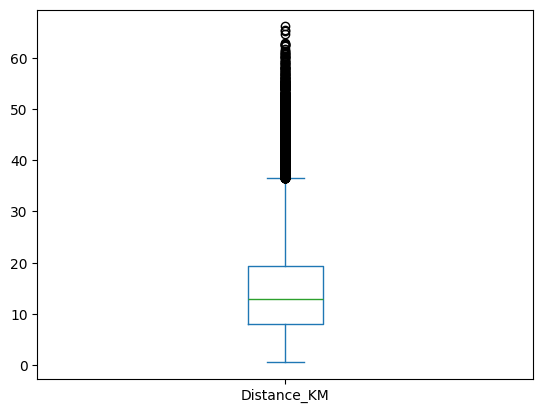

In [112]:
Num_Features['Distance_KM'].plot(kind='box')

<Axes: >

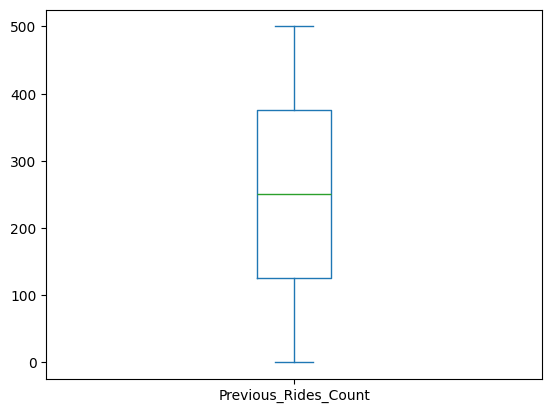

In [113]:
Num_Features['Previous_Rides_Count'].plot(kind='box')

<Axes: ylabel='Frequency'>

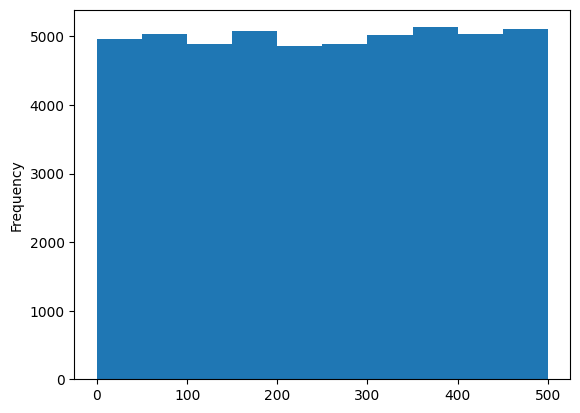

In [114]:
Num_Features['Previous_Rides_Count'].plot(kind='hist')

In [115]:
Cat_Featues

,Day_of_Week,Month,City,Pickup_Area,Dropoff_Area,Vehicle_Type,Customer_Segment,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason
0,saturday,june,hyderabad,madhapur,ameerpet,uberauto,new,sunny,very high,wallet,home,not_available,no driver available
1,wednesday,may,chennai,mylapore,nungambakkam,ubergo,occasional,cloudy,moderate,cash,other,save20,not_available
2,friday,april,pune,viman nagar,hinjewadi,uberauto,regular,cloudy,very high,debit card,work,save20,not_available
3,monday,february,chennai,tambaram,guindy,uberpremier,premium,drizzle,medium,amazon pay,social,not_available,not_available
4,wednesday,january,kolkata,park street,howrah,uberauto,new,partly cloudy,high,upi,party,not_available,not_available
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,tuesday,november,hyderabad,kukatpally,secunderabad,ubermoto,frequent,fog,heavy,cash,meeting,not_available,not_available
51246,monday,april,ahmedabad,navrangpura,naranpura,ubermoto,new,light rain,high,phonepe,social,not_available,not_available
51247,tuesday,may,chennai,perungudi,sholinganallur,uberxl,frequent,light rain,moderate,phonepe,party,not_available,not_available
51248,friday,june,bangalore,koramangala,mg road,ubermoto,frequent,heavy rain,heavy,upi,hospital,not_available,not_available


In [116]:
Num_Features

,Hour_of_Day,Is_Weekend,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,Driver_Rating,Driver_Experience_Years,Driver_Acceptance_Rate,Temperature_Celsius,Surge_Multiplier,Is_Scheduled_Ride,Is_Shared_Ride,Number_of_Passengers,Waiting_Time_Minutes,Tip_Amount,Discount_Applied
0,20,1,21.47,4.9,91,0.21,4.5,1,0.77,19.4,1.9,0,0,4,0.0,0.0,0.00
1,1,0,17.83,4.6,167,0.11,4.6,1,0.91,20.8,1.0,0,0,2,13.6,0.0,95.26
2,21,0,8.90,5.0,204,0.24,3.5,8,0.77,15.4,1.7,0,0,3,6.4,0.0,35.17
3,11,0,7.03,4.8,85,0.12,4.7,2,0.91,41.0,1.9,0,0,4,3.3,50.0,0.00
4,22,0,13.79,4.3,91,0.05,4.5,1,0.81,15.2,1.2,0,0,4,2.1,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,7,0,10.44,4.6,302,0.08,4.3,9,0.73,33.4,2.3,0,0,1,6.9,0.0,0.00
51246,4,0,13.76,4.2,231,0.14,4.9,2,0.81,32.3,1.5,0,0,3,7.3,0.0,0.00
51247,18,0,13.16,4.2,340,0.10,4.6,7,0.92,38.1,1.8,0,0,2,13.7,0.0,0.00
51248,16,0,21.44,4.9,42,0.05,4.3,10,0.78,32.4,2.0,0,0,3,13.8,0.0,87.39


In [117]:
y_Target

,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,0.0,0.00,Failed
1,35.6,275.78,Success
2,47.0,270.06,Success
3,27.9,722.24,Success
4,50.0,239.50,Success
...,...,...,...
51245,63.7,321.67,Success
51246,54.1,223.22,Success
51247,42.9,565.34,Success
51248,123.1,472.46,Success


In [118]:
Cleaned_Df = pd.concat([Num_Features, Cat_Featues, y_Target], axis=1)
Cleaned_Df

,Hour_of_Day,Is_Weekend,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,Driver_Rating,Driver_Experience_Years,Driver_Acceptance_Rate,Temperature_Celsius,...,Customer_Segment,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,20,1,21.47,4.9,91,0.21,4.5,1,0.77,19.4,...,new,sunny,very high,wallet,home,not_available,no driver available,0.0,0.00,Failed
1,1,0,17.83,4.6,167,0.11,4.6,1,0.91,20.8,...,occasional,cloudy,moderate,cash,other,save20,not_available,35.6,275.78,Success
2,21,0,8.90,5.0,204,0.24,3.5,8,0.77,15.4,...,regular,cloudy,very high,debit card,work,save20,not_available,47.0,270.06,Success
3,11,0,7.03,4.8,85,0.12,4.7,2,0.91,41.0,...,premium,drizzle,medium,amazon pay,social,not_available,not_available,27.9,722.24,Success
4,22,0,13.79,4.3,91,0.05,4.5,1,0.81,15.2,...,new,partly cloudy,high,upi,party,not_available,not_available,50.0,239.50,Success
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51245,7,0,10.44,4.6,302,0.08,4.3,9,0.73,33.4,...,frequent,fog,heavy,cash,meeting,not_available,not_available,63.7,321.67,Success
51246,4,0,13.76,4.2,231,0.14,4.9,2,0.81,32.3,...,new,light rain,high,phonepe,social,not_available,not_available,54.1,223.22,Success
51247,18,0,13.16,4.2,340,0.10,4.6,7,0.92,38.1,...,frequent,light rain,moderate,phonepe,party,not_available,not_available,42.9,565.34,Success
51248,16,0,21.44,4.9,42,0.05,4.3,10,0.78,32.4,...,frequent,heavy rain,heavy,upi,hospital,not_available,not_available,123.1,472.46,Success


In [119]:
Cleaned_Df.to_csv('uber_data_cleaned.csv', index=False)

In [120]:
try:
  Cleaned_Df = pd.read_csv('uber_data_cleaned.csv')
  Cleaned_Df.head()
  print("Data loaded successfully")
except Exception as e:
  print(e)

Data loaded successfully


In [121]:
Cleaned_Df.head()

,Hour_of_Day,Is_Weekend,Distance_KM,Customer_Rating,Previous_Rides_Count,Customer_Cancellation_Rate,Driver_Rating,Driver_Experience_Years,Driver_Acceptance_Rate,Temperature_Celsius,...,Customer_Segment,Weather_Condition,Traffic_Condition,Payment_Method,Ride_Purpose,Coupon_Code,Cancellation_Reason,ETA_Minutes,Fare_Price,Driver_Pickup_Status
0,20,1,21.47,4.9,91,0.21,4.5,1,0.77,19.4,...,new,sunny,very high,wallet,home,not_available,no driver available,0.0,0.00,Failed
1,1,0,17.83,4.6,167,0.11,4.6,1,0.91,20.8,...,occasional,cloudy,moderate,cash,other,save20,not_available,35.6,275.78,Success
2,21,0,8.90,5.0,204,0.24,3.5,8,0.77,15.4,...,regular,cloudy,very high,debit card,work,save20,not_available,47.0,270.06,Success
3,11,0,7.03,4.8,85,0.12,4.7,2,0.91,41.0,...,premium,drizzle,medium,amazon pay,social,not_available,not_available,27.9,722.24,Success
4,22,0,13.79,4.3,91,0.05,4.5,1,0.81,15.2,...,new,partly cloudy,high,upi,party,not_available,not_available,50.0,239.50,Success
